# Linear regression

## Implement from scratch

In [1]:
import numpy as np

In [2]:
def compute_predictions(X, weights):
    predictions = np.dot(X, weights)
    return predictions

In [3]:
def update_weights_gd(X_train, y_train, weights, learning_rate):
    predictions = compute_predictions(X_train, weights)
    m = X_train.shape[0]
    gradient = np.dot(predictions - y_train, X_train) / m
    weights += - learning_rate * gradient
    return weights

In [4]:
def compute_cost(X_train, y_train, weights):
    m = y_train.shape[0]
    predictions = compute_predictions(X_train, weights)
    return np.mean((predictions - y_train)**2 / 2.0)

In [5]:
def train_linear_regression(X_train, y_train, max_iter, learning_rate, fit_intercept=False):
    if fit_intercept:
        intercept = np.ones((X_train.shape[0], 1))
        X_train = np.hstack((intercept, X_train))
    weights = np.zeros(X_train.shape[1])
    for iteration in range(max_iter):
        weights = update_weights_gd(X_train, y_train, weights, learning_rate)
        if iteration % 100 == 0:
            print(compute_cost(X_train, y_train, weights))
    return weights

In [6]:
def predict(X, weights):
    if X.shape[1] == weights.shape[0] - 1:
        intercept = np.ones((X.shape[0], 1))
        X = np.hstack((intercept, X))
    return compute_predictions(X, weights)

In [7]:
X_train = np.array([[6], [2], [3], [4], [1], [5], [2], [6], [4], [7]])
y_train = np.array([5.5, 1.6, 2.2, 3.7, 0.8, 5.2, 1.5, 5.3, 4.4, 6.8])

weights = train_linear_regression(X_train, y_train, max_iter=1000, learning_rate=0.01, fit_intercept=True)

5.571972628
0.08086015122228847
0.07548404733627607
0.07170632283789724
0.06905176059575331
0.06718643116253492
0.06587568627240162
0.06495464136933257
0.06430743402955555
0.06385264910075839


In [8]:
X_test = np.array([[1.3], [3.5], [5.2], [2.8]])
predictions = predict(X_test, weights)

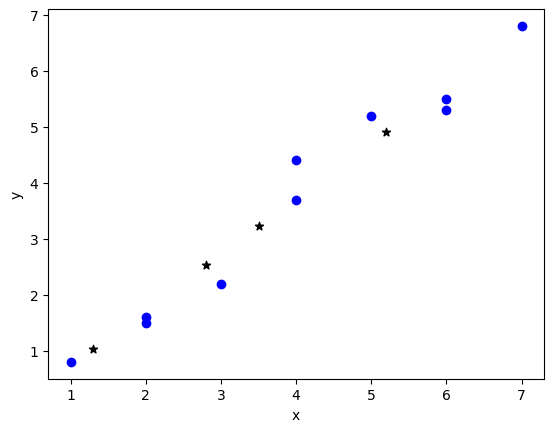

In [9]:
import matplotlib.pyplot as plt
plt.scatter(X_train[:, 0], y_train, marker='o', c='b')
plt.scatter(X_test[:, 0], predictions, marker='*', c='k')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### Diabetes dataset

In [10]:
from sklearn import datasets

In [11]:
diabetes = datasets.load_diabetes()
print(diabetes.data.shape)

(442, 10)


In [12]:
num_test = 30
X_train = diabetes.data[:-num_test, :]
y_train = diabetes.target[:-num_test]
X_test = diabetes.data[-num_test:, :]
y_test = diabetes.target[-num_test:]

In [13]:
weights = train_linear_regression(X_train, y_train, max_iter=5000, learning_rate=1, fit_intercept=True)

2960.123025607216
1984.7486632548823
1729.7769635921995
1627.6348119343263
1572.763273052353
1539.554802043756
1518.618109725916
1505.191691946131
1496.4882691586806
1490.7927148484966
1487.0293572901583
1484.516650020924
1482.8194344074193
1481.6579404201677
1480.8510951067901
1480.280921685538
1479.870031213809
1479.5673033510566
1479.3387231207394
1479.1614836837493
1479.0201696937395
1478.9042732451073
1478.8065678119995
1478.7220374658161
1478.6471673310045
1478.57947029736
1478.5171691036435
1478.4589811941235
1478.4039719757411
1478.3514538988786
1478.3009164521106
1478.2519771680845
1478.204347022648
1478.157805775425
1478.1121842360592
1478.0673513977843
1478.0232050223478
1477.9796646941397
1477.9366666564356
1477.8941599449038
1477.8521034731898
1477.8104638227055
1477.7692135570753
1477.7283299301287
1477.6877938909208
1477.647589314213
1477.6077024029764
1477.5681212227464
1477.5288353374858
1477.4898355238697


In [14]:
predictions = predict(X_test, weights)

print(predictions)
print(y_test)

[232.22192119 123.87532386 166.12297497 170.23855082 228.12523411
 154.9570854  101.09011561  87.33479691 143.68827095 190.29424697
 198.00696804 149.63068784 169.56215468 109.01832867 161.97943375
 133.00757288 260.18431805 101.52516612 115.76691141 120.73229914
 219.62761982  62.21080727 136.29855757 122.27895603  55.14532638
 191.50289376 105.68864904 126.26137526 208.99754096  47.66481183]
[261. 113. 131. 174. 257.  55.  84.  42. 146. 212. 233.  91. 111. 152.
 120.  67. 310.  94. 183.  66. 173.  72.  49.  64.  48. 178. 104. 132.
 220.  57.]


## Use sklearn

In [15]:
from sklearn.linear_model import SGDRegressor

In [16]:
regressor = SGDRegressor(loss='squared_error', penalty='l2', alpha=0.0001, learning_rate='constant', eta0=0.01, max_iter=1000)

In [17]:
regressor.fit(X_train, y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [18]:
predictions = regressor.predict(X_test)
print(predictions)

[217.72172732 130.53476274 193.89739564 174.83039921 207.95328353
 148.78375727 129.11798381  99.59799388 160.96664422 199.79276454
 192.8888197  172.37031121 176.26671567  97.59649195 189.27095179
 139.16321085 252.09091994 116.18153999 134.40869863 134.72967843
 214.06914335  89.6923261  144.00547956 129.20424232  70.71399181
 189.42713831 143.5772616  144.6758434  190.08974978  80.0243597 ]


## Use PyTorch

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

In [20]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

In [21]:
model = nn.Sequential(nn.Linear(X_train.shape[1], 1))
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1)

In [22]:
model.train()
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(X_train_t).squeeze(1)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.4f}")

Epoch 0: loss = 29506.4023
Epoch 100: loss = 8826.1436
Epoch 200: loss = 4061.2363
Epoch 300: loss = 3335.5659
Epoch 400: loss = 3159.8025
Epoch 500: loss = 3081.2153
Epoch 600: loss = 3039.0427
Epoch 700: loss = 3013.5408
Epoch 800: loss = 2996.9563
Epoch 900: loss = 2985.8264


In [23]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_t).squeeze(1).numpy()
print(predictions)

[230.62927  123.80347  166.7282   172.19186  228.09985  150.39856
 102.8176    93.63077  152.5541   190.6702   188.51213  155.26418
 168.58905  106.02869  167.75069  133.18207  258.43787  101.76059
 120.406395 121.15554  218.02307   66.6943   138.15927  124.26762
  57.81453  188.4268   107.33505  129.4932   204.96506   48.941254]
